# Regressão Multi-Output com Random Forest
Pipeline completo: definição do problema, limpeza, EDA, engenharia de features, treino/validação, interpretabilidade e salvamento do modelo.

## Objetivo
Prever simultaneamente os cinco traços (Big Five) `trait_extraversion`, `trait_agreeableness`, `trait_conscientiousness`, `trait_neuroticism` e `trait_openness` usando dados demográficos/educacionais do dataset `data/processed_moz_students.csv`.

In [ ]:
# Imports principais
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)


In [70]:
# Paths e leitura
DATA_PATH = Path('../data/processed_moz_students.csv')
assert DATA_PATH.exists(), f'Arquivo não encontrado: {DATA_PATH}'
df = pd.read_csv(DATA_PATH)
df.shape, df.head()

((1863, 16),
    Gender Age (Years)           region_moz region_macro  \
 0    Male          38              Nampula        Norte   
 1  Female          20                 Tete       Centro   
 2    Male          20              Nampula        Norte   
 3    Male          20              Nampula        Norte   
 4    Male          22  Província de Maputo          Sul   
 
                      grade_band     school_type ria_sec_letters  \
 0  Pré-universitário / Ano Zero  Escola Privada             I-A   
 1                    12ª Classe  Escola Pública             S-A   
 2                    12ª Classe  Escola Pública             S-A   
 3                    12ª Classe  Escola Pública             S-A   
 4                    12ª Classe  Escola Pública             C-R   
 
                                       career_desc_en  \
 0  Investigator who thrives on experiments, data,...   
 1  Human-centered shaper who codes, designs, or f...   
 2  Human-centered shaper who codes, designs

In [50]:
# Tipos e valores ausentes
buf = StringIO()
df.info(buf=buf)
print(buf.getvalue())
print("Ausências absolutas:")
display(df.isna().sum().sort_values(ascending=False).to_frame('n_missing'))
print("Estatísticas numéricas:")
display(df.describe(include=[np.number]).T)

<class 'pandas.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   1863 non-null   str    
 1   Age (Years)              1863 non-null   str    
 2   region_moz               1863 non-null   str    
 3   region_macro             1863 non-null   str    
 4   grade_band               1863 non-null   str    
 5   school_type              1863 non-null   str    
 6   ria_sec_letters          1863 non-null   str    
 7   career_desc_en           1863 non-null   str    
 8   career_desc_pt           1863 non-null   str    
 9   career_examples_en       1863 non-null   str    
 10  career_examples_pt       1863 non-null   str    
 11  trait_extraversion       1863 non-null   float64
 12  trait_agreeableness      1863 non-null   float64
 13  trait_conscientiousness  1863 non-null   float64
 14  trait_neuroticism        1863 non-n

,n_missing
Gender,0
Age (Years),0
region_moz,0
region_macro,0
grade_band,0
school_type,0
ria_sec_letters,0
career_desc_en,0
career_desc_pt,0
career_examples_en,0


Estatísticas numéricas:


,count,mean,std,min,25%,50%,75%,max
trait_extraversion,1863.0,3.105475,0.742678,1.0,2.5,3.0,3.5,5.0
trait_agreeableness,1863.0,2.392915,0.735178,1.0,2.0,2.5,3.0,5.0
trait_conscientiousness,1863.0,2.742351,0.793478,1.0,2.0,2.5,3.0,5.0
trait_neuroticism,1863.0,3.221685,0.868640,1.0,2.5,3.0,4.0,5.0
trait_openness,1863.0,2.751744,0.671233,1.0,2.5,3.0,3.0,5.0


## EDA rápida
Ver distribuição dos alvos e inspeção de correlações numéricas.

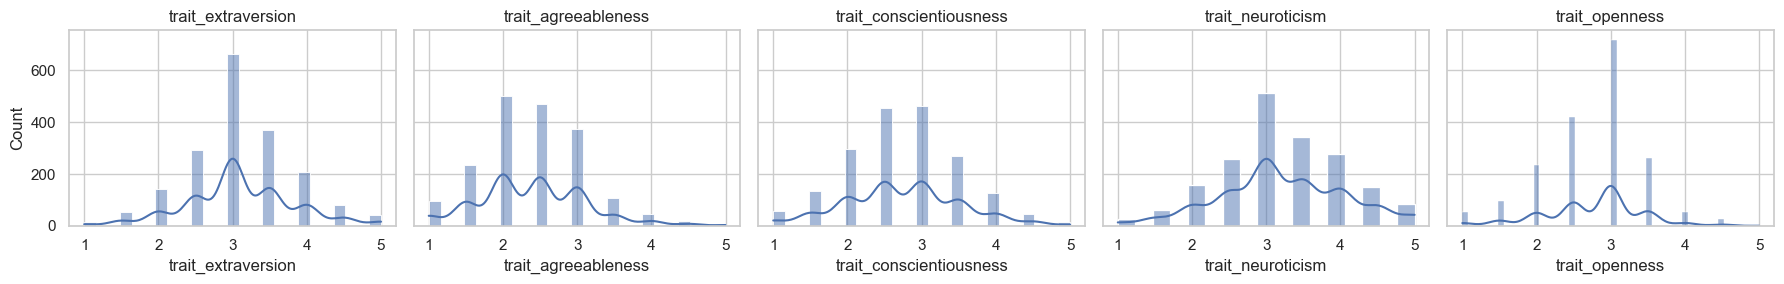

In [51]:
# Distribuição dos alvos
target_cols = ['trait_extraversion', 'trait_agreeableness', 'trait_conscientiousness', 'trait_neuroticism', 'trait_openness']
fig, axes = plt.subplots(1, len(target_cols), figsize=(18, 3), sharey=True)
for ax, col in zip(axes, target_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

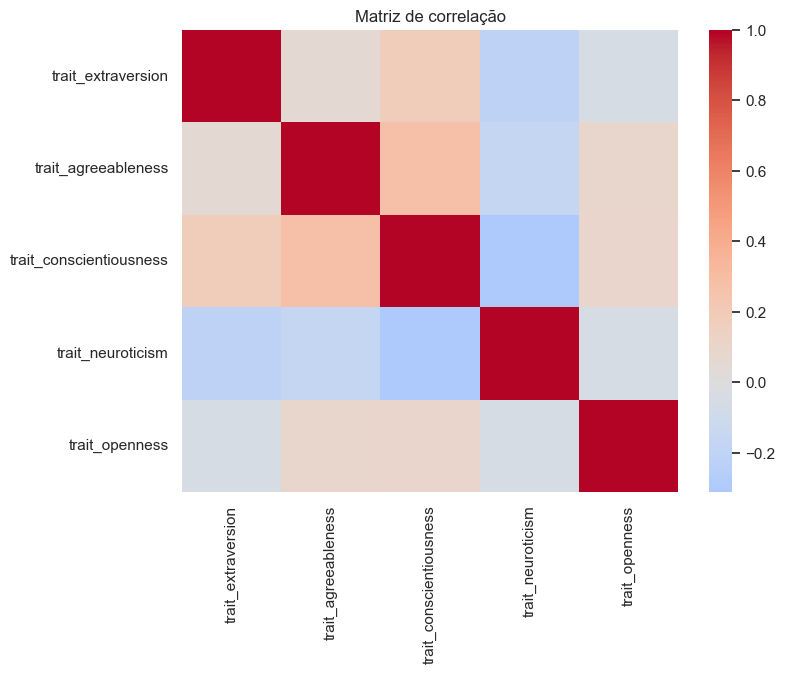

In [52]:
# Correlação numérica (inclui alvos e idade)
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.show()

## Engenharia de features e limpeza
- Remover textos longos (`career_desc_*`, `career_examples_*`) para simplificar.
- Separar colunas categóricas vs numéricas.
- Tratar faltantes com imputação simples.
- One-hot encoding nas categorias.

In [71]:
# Engenharia de features

df_fe = df.copy()

# Assegurar coluna de idade numérica para criar faixas
df_fe['Age (Years)'] = pd.to_numeric(df_fe['Age (Years)'], errors='coerce')

# One-hot de letras RIASEC
letters = list('RIASEC')
for letter in letters:
    df_fe[f'ria_{letter}'] = df_fe['ria_sec_letters'].fillna('').str.contains(letter).astype(int)

# Buckets de idade (categorias)
age_bins = [-np.inf, 18, 20, 22, np.inf]
age_labels = ['<=18', '19-20', '21-22', '>=23']
df_fe['age_bucket'] = pd.cut(df_fe['Age (Years)'], bins=age_bins, labels=age_labels).astype(str)

# Agrupar categorias raras
def group_rare(series, min_frac=0.02):
    counts = series.value_counts(normalize=True)
    keep = counts[counts >= min_frac].index
    return series.where(series.isin(keep), 'Other')

for col in ['region_moz', 'grade_band', 'school_type']:
    if col in df_fe.columns:
        df_fe[col] = group_rare(df_fe[col])

# Definir conjuntos de colunas (sem TF-IDF: remove todas as colunas de texto de carreira)
target_cols = ['trait_extraversion', 'trait_agreeableness', 'trait_conscientiousness', 'trait_neuroticism', 'trait_openness']
text_drop_cols = [
    'career_desc_en', 'career_desc_pt',
    'career_examples_en', 'career_examples_pt',
    'career_text_all'
]
X = df_fe.drop(columns=target_cols + text_drop_cols, errors='ignore')
y = df_fe[target_cols].copy()

cat_cols = sorted(set(
    [c for c in X.select_dtypes(include=['object', 'category']).columns.tolist()] + ['age_bucket']
))
num_cols = [c for c in X.select_dtypes(include=['number']).columns.tolist() if c not in cat_cols]

print("cat_cols:", cat_cols)
print("num_cols:", num_cols)
cat_cols, num_cols


cat_cols: ['Gender', 'age_bucket', 'grade_band', 'region_macro', 'region_moz', 'ria_sec_letters', 'school_type']
num_cols: ['Age (Years)', 'ria_R', 'ria_I', 'ria_A', 'ria_S', 'ria_E', 'ria_C']


C:\Users\user\AppData\Local\Temp\ipykernel_13280\788744372.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  [c for c in X.select_dtypes(include=['object', 'category']).columns.tolist()] + ['age_bucket']


(['Gender',
  'age_bucket',
  'grade_band',
  'region_macro',
  'region_moz',
  'ria_sec_letters',
  'school_type'],
 ['Age (Years)', 'ria_R', 'ria_I', 'ria_A', 'ria_S', 'ria_E', 'ria_C'])

In [72]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)
X_train.shape, X_test.shape

((1490, 14), (373, 14))

In [73]:
# Pipeline de pré-processamento + modelo (recalcula listas de colunas para manter sincronizado)

# Categóricas (objetos/categorias), garantindo age_bucket
cat_cols = sorted(set(
    [c for c in X.select_dtypes(include=['object', 'category']).columns.tolist()] + ['age_bucket']
))

# Numéricas = restantes que não são categóricas
num_cols = [c for c in X.columns if c not in cat_cols]

print("cat_cols:", cat_cols)
print("num_cols:", num_cols)

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, cat_cols),
        ('num', numeric_pipeline, num_cols),
    ]
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', MultiOutputRegressor(rf_reg))
])
model


cat_cols: ['Gender', 'age_bucket', 'grade_band', 'region_macro', 'region_moz', 'ria_sec_letters', 'school_type']
num_cols: ['Age (Years)', 'ria_R', 'ria_I', 'ria_A', 'ria_S', 'ria_E', 'ria_C']


C:\Users\user\AppData\Local\Temp\ipykernel_13280\986264268.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  [c for c in X.select_dtypes(include=['object', 'category']).columns.tolist()] + ['age_bucket']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Validação cruzada
Métricas: MAE, RMSE e R² (médias macro).

In [74]:
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
)
summary = {
    'MAE_cv_mean': -cv_results['test_mae'].mean(),
    'MAE_cv_std': cv_results['test_mae'].std(),
    'RMSE_cv_mean': -cv_results['test_rmse'].mean(),
    'RMSE_cv_std': cv_results['test_rmse'].std(),
    'R2_cv_mean': cv_results['test_r2'].mean(),
    'R2_cv_std': cv_results['test_r2'].std(),
}
summary

{'MAE_cv_mean': np.float64(0.6558789233117193),
 'MAE_cv_std': np.float64(0.007454919432864923),
 'RMSE_cv_mean': np.float64(0.8319755249258151),
 'RMSE_cv_std': np.float64(0.010581455601578303),
 'R2_cv_mean': np.float64(-0.19856640440594547),
 'R2_cv_std': np.float64(0.03193724653635187)}

## Diagnóstico rápido de variância dos alvos e baseline

In [75]:
# Dispersão/variância dos alvos
target_stats = pd.DataFrame({
    'mean': y.mean(),
    'std': y.std(),
    'var': y.var()
})
display(target_stats)

,mean,std,var
trait_extraversion,3.105475,0.742678,0.551570
trait_agreeableness,2.392915,0.735178,0.540487
trait_conscientiousness,2.742351,0.793478,0.629607
trait_neuroticism,3.221685,0.868640,0.754535
trait_openness,2.751744,0.671233,0.450554


In [76]:
# Baseline DummyRegressor (prevê média)
from sklearn.dummy import DummyRegressor

dummy_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('dummy', MultiOutputRegressor(DummyRegressor(strategy='mean')))
])

dummy_model.fit(X_train, y_train)
y_dummy = dummy_model.predict(X_test)
y_dummy_df = pd.DataFrame(y_dummy, columns=target_cols, index=X_test.index)

baseline_metrics = {}
for col in target_cols:
    mae = mean_absolute_error(y_test[col], y_dummy_df[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_dummy_df[col]))
    r2 = r2_score(y_test[col], y_dummy_df[col])
    baseline_metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('Baseline Dummy (hold-out):')
display(pd.DataFrame(baseline_metrics).T)

baseline_overall = {
    'MAE_macro': np.mean([m['MAE'] for m in baseline_metrics.values()]),
    'RMSE_macro': np.mean([m['RMSE'] for m in baseline_metrics.values()]),
    'R2_macro': np.mean([m['R2'] for m in baseline_metrics.values()])
}
print('Baseline overall (macro):', baseline_overall)
baseline_overall

Baseline Dummy (hold-out):


,MAE,RMSE,R2
trait_extraversion,0.614394,0.800635,-0.000235
trait_agreeableness,0.559708,0.722724,-0.000665
trait_conscientiousness,0.644039,0.805065,-0.000335
trait_neuroticism,0.719431,0.899716,-0.002108
trait_openness,0.516321,0.656614,-0.000021


Baseline overall (macro): {'MAE_macro': np.float64(0.6107785594760422), 'RMSE_macro': np.float64(0.7769508387711304), 'R2_macro': np.float64(-0.0006728389659309108)}


{'MAE_macro': np.float64(0.6107785594760422),
 'RMSE_macro': np.float64(0.7769508387711304),
 'R2_macro': np.float64(-0.0006728389659309108)}

## Treino final e avaliação hold-out

## Tuning e modelos alternativos

In [77]:
# Busca aleatória para RF e ExtraTrees (3 folds)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
import scipy.stats as st

rf_base = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)))
])

et_base = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', MultiOutputRegressor(ExtraTreesRegressor(random_state=42, n_jobs=-1)))
])

param_dist_rf = {
    'clf__estimator__n_estimators': st.randint(400, 801),
    'clf__estimator__max_depth': [5, 8, 12, None],
    'clf__estimator__min_samples_leaf': [2, 3, 4],
    'clf__estimator__max_features': ['sqrt', 'log2', 0.3, 0.5],
}

param_dist_et = {
    'clf__estimator__n_estimators': st.randint(400, 801),
    'clf__estimator__max_depth': [5, 8, 12, None],
    'clf__estimator__min_samples_leaf': [2, 3, 4],
    'clf__estimator__max_features': ['sqrt', 'log2', 0.3, 0.5],
}

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring=scoring,
    refit='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

et_search = RandomizedSearchCV(
    et_base,
    param_distributions=param_dist_et,
    n_iter=10,
    cv=3,
    scoring=scoring,
    refit='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Rodando RandomizedSearchCV para Random Forest...')
rf_search.fit(X_train, y_train)
print('Melhor R2 (cv):', rf_search.best_score_)
print('Melhores params RF:', rf_search.best_params_)

print('\nRodando RandomizedSearchCV para ExtraTrees...')
et_search.fit(X_train, y_train)
print('Melhor R2 (cv):', et_search.best_score_)
print('Melhores params ET:', et_search.best_params_)

best_rf = rf_search.best_estimator_
best_et = et_search.best_estimator_

Rodando RandomizedSearchCV para Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhor R2 (cv): 0.02530030096415931
Melhores params RF: {'clf__estimator__max_depth': 5, 'clf__estimator__max_features': 'log2', 'clf__estimator__min_samples_leaf': 3, 'clf__estimator__n_estimators': 693}

Rodando RandomizedSearchCV para ExtraTrees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhor R2 (cv): 0.02659904494383272
Melhores params ET: {'clf__estimator__max_depth': 5, 'clf__estimator__max_features': 'log2', 'clf__estimator__min_samples_leaf': 3, 'clf__estimator__n_estimators': 693}


In [78]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=target_cols, index=X_test.index)
metrics = {}
for col in target_cols:
    mae = mean_absolute_error(y_test[col], y_pred_df[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred_df[col]))
    r2 = r2_score(y_test[col], y_pred_df[col])
    metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
display(pd.DataFrame(metrics).T)
overall = {
    'MAE_macro': np.mean([m['MAE'] for m in metrics.values()]),
    'RMSE_macro': np.mean([m['RMSE'] for m in metrics.values()]),
    'R2_macro': np.mean([m['R2'] for m in metrics.values()])
}
overall

,MAE,RMSE,R2
trait_extraversion,0.690351,0.874966,-0.194581
trait_agreeableness,0.579890,0.748383,-0.072978
trait_conscientiousness,0.684775,0.861642,-0.145874
trait_neuroticism,0.765978,0.978774,-0.185955
trait_openness,0.549793,0.717242,-0.193221


{'MAE_macro': np.float64(0.6541574271429245),
 'RMSE_macro': np.float64(0.8362012489631516),
 'R2_macro': np.float64(-0.15852164228640192)}

In [79]:
# Avaliação hold-out: best RF, best ExtraTrees e baseline
def eval_model(estimator, X_te, y_te, label):
    y_hat = estimator.predict(X_te)
    y_hat_df = pd.DataFrame(y_hat, columns=target_cols, index=X_te.index)
    metrics = {}
    for col in target_cols:
        mae = mean_absolute_error(y_te[col], y_hat_df[col])
        rmse = np.sqrt(mean_squared_error(y_te[col], y_hat_df[col]))
        r2 = r2_score(y_te[col], y_hat_df[col])
        metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    macro = {
        'MAE_macro': np.mean([m['MAE'] for m in metrics.values()]),
        'RMSE_macro': np.mean([m['RMSE'] for m in metrics.values()]),
        'R2_macro': np.mean([m['R2'] for m in metrics.values()])
    }
    print(f'== {label} ==')
    display(pd.DataFrame(metrics).T)
    print('Macro:', macro)
    return macro

# Reutiliza baseline já calculado (baseline_overall)
rf_macro = eval_model(best_rf, X_test, y_test, 'Best RF (hold-out)')
et_macro = eval_model(best_et, X_test, y_test, 'Best ExtraTrees (hold-out)')

# Modelo RF original para referência
model.fit(X_train, y_train)
rf_orig_macro = eval_model(model, X_test, y_test, 'RF original (hold-out)')

summary_compare = pd.DataFrame([
    {'model': 'Baseline Dummy', **baseline_overall},
    {'model': 'RF original', **rf_orig_macro},
    {'model': 'RF tuned', **rf_macro},
    {'model': 'ExtraTrees tuned', **et_macro},
])
summary_compare

== Best RF (hold-out) ==


,MAE,RMSE,R2
trait_extraversion,0.621544,0.806113,-0.013970
trait_agreeableness,0.550816,0.712560,0.027283
trait_conscientiousness,0.623993,0.781133,0.058256
trait_neuroticism,0.680894,0.869320,0.064458
trait_openness,0.506849,0.648788,0.023672


Macro: {'MAE_macro': np.float64(0.5968190383687471), 'RMSE_macro': np.float64(0.7635830222282642), 'R2_macro': np.float64(0.031939743454765156)}
== Best ExtraTrees (hold-out) ==


,MAE,RMSE,R2
trait_extraversion,0.621600,0.806260,-0.014338
trait_agreeableness,0.551003,0.712215,0.028226
trait_conscientiousness,0.623680,0.780667,0.059378
trait_neuroticism,0.680413,0.869404,0.064279
trait_openness,0.506033,0.647532,0.027451


Macro: {'MAE_macro': np.float64(0.5965457121676218), 'RMSE_macro': np.float64(0.7632153570557926), 'R2_macro': np.float64(0.03299909782186703)}
== RF original (hold-out) ==


,MAE,RMSE,R2
trait_extraversion,0.690351,0.874966,-0.194581
trait_agreeableness,0.579890,0.748383,-0.072978
trait_conscientiousness,0.684775,0.861642,-0.145874
trait_neuroticism,0.765978,0.978774,-0.185955
trait_openness,0.549793,0.717242,-0.193221


Macro: {'MAE_macro': np.float64(0.6541574271429242), 'RMSE_macro': np.float64(0.8362012489631516), 'R2_macro': np.float64(-0.15852164228640192)}


,model,MAE_macro,RMSE_macro,R2_macro
0,Baseline Dummy,0.610779,0.776951,-0.000673
1,RF original,0.654157,0.836201,-0.158522
2,RF tuned,0.596819,0.763583,0.031940
3,ExtraTrees tuned,0.596546,0.763215,0.032999


## Importância de features
Usamos `permutation_importance` no conjunto de teste. Valores maiores indicam maior contribuição média para todos os alvos.

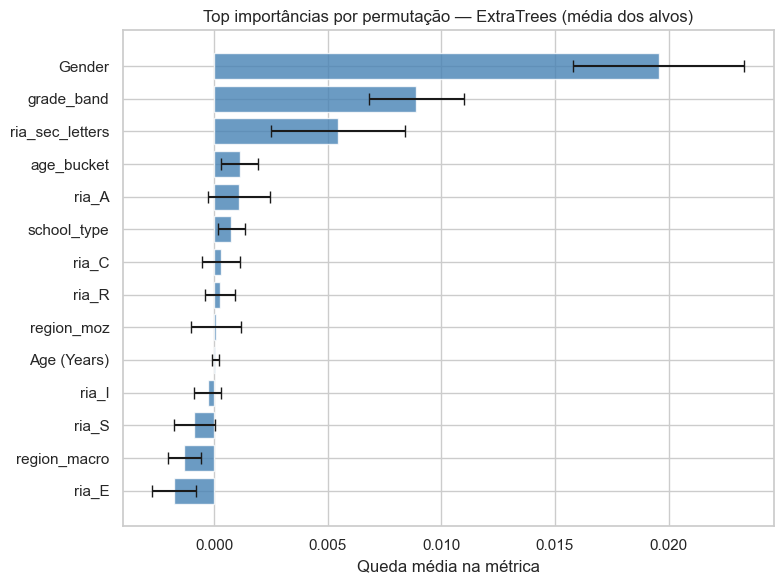

,feature,importance_mean,importance_std
0,Gender,0.019558,0.003778
1,grade_band,0.008908,0.002083
2,ria_sec_letters,0.005471,0.002952
3,age_bucket,0.001127,0.000806
4,ria_A,0.001096,0.001354
5,school_type,0.000763,0.000589
6,ria_C,0.000324,0.000834
7,ria_R,0.000268,0.000655
8,region_moz,0.000099,0.001096
9,Age (Years),0.000051,0.000152


In [ ]:
# Permutation importance (pode levar alguns segundos)
# Usa best_et; opera no espaço de entrada (antes do OHE) → nomes = X_test.columns
from sklearn.utils import Bunch
result = permutation_importance(
    best_et, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
assert isinstance(result, Bunch), "Unexpected result type"

importances_mean = result.importances_mean
importances_std = result.importances_std
if importances_mean.ndim > 1:
    importances_mean = importances_mean.mean(axis=0)
    importances_std = importances_std.mean(axis=0)

# Nomes de colunas de entrada (antes do pré-processamento)
feature_names = list(X_test.columns)

importances = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': importances_mean,
    'importance_std': importances_std
}).sort_values('importance_mean', ascending=False)

topk = importances.head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    topk['feature'][::-1],
    topk['importance_mean'][::-1],
    xerr=topk['importance_std'][::-1].values,
    align='center', color='steelblue', alpha=0.8, capsize=4
)
ax.set_title('Top importâncias por permutação — ExtraTrees (média dos alvos)')
ax.set_xlabel('Queda média na métrica')
plt.tight_layout()
plt.show()

topk

## Salvar modelo e pré-processador
Salvamos em `.pkl` para reuso em inferência/produção.

In [83]:
artifacts_dir = Path('models')
artifacts_dir.mkdir(parents=True, exist_ok=True)
model_path = artifacts_dir / 'multioutput_et_tuned.pkl'
joblib.dump(best_et, model_path)
model_path

WindowsPath('models/multioutput_et_tuned.pkl')

## Próximos passos
1. Testar `RandomForestRegressor` com ajuste de hiperparâmetros (n_estimators, max_features, max_depth).
2. Avaliar modelos baseados em `XGBoost`/`LightGBM` para possível ganho de R².
3. Adicionar embeddings resumidos das descrições de carreira se desejar maior sinal.
4. Validar estabilidade via repeated K-fold ou bootstrap.